<a href="https://colab.research.google.com/github/ava-ly/ds-projects/blob/main/Project_Netflix_Content_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Netflix Content Analysis & Predictive Model Development

<img src='https://github.com/ava-ly/ds-projects/raw/main/netflix/netflix-banner.jpg'>

# The Big Question

- (EDA) What are the key characteristics and creative elements that define successful and engaging Netflix movies and TV shows.

- (ML) How can we leverage these data-driven insights to build a predictive model to estimate a show/movie's IMDb score?



---


# Project Plan

## 1. Project Objective(s):

*   **Primary:**
    1.  To perform a comprehensive exploratory data analysis (EDA) of the Netflix content library to uncover trends, patterns, and insights regarding content types, genres, ratings, production countries, and key creative personnel (directors/actors).
    2.  To build a predictive model to estimate a show/movie's IMDb score based on its characteristics.
    
*   **Secondary (Optional):**
    1.  To develop a content-based recommendation system that suggests similar movies/TV shows based on their attributes.
    2.  To identify factors that correlate with highly-rated or popular content.

## 2. Dataset:

*   **Source:** Kaggle - "Netflix TV Shows and Movies" by Victor Soeiro
*   **Files:**
    *   `titles.csv`: Contains metadata about movies and TV shows (title, description, release year, genres, IMDb scores, etc.)
    *   `credits.csv`: Contains information about directors and cast members for each title.
*   **Link:** [https://www.kaggle.com/datasets/victorsoeiro/netflix-tv-shows-and-movies](https://www.kaggle.com/datasets/victorsoeiro/netflix-tv-shows-and-movies)

## 3. Project Tasks:

### 3.1 Data Loading, Cleaning & Preprocessing

*   Load `titles.csv` and `credits.csv` into Pandas DataFrames.
*   Initial data inspection: `.head()`, `.info()`, `.describe()`, `.shape`, check for duplicates.
*   Handle Missing Values:
    *   Identify columns with missing values (e.g., `age_certification`, `imdb_score`, `seasons`).
    *   Devise a strategy for each: imputation (mean, median, mode, "Unknown") or removal. Document choices.
*   Data Type Conversion:
    *   Ensure `release_year` is numeric, `runtime` is numeric.
    *   Convert `seasons`, `imdb_score`, `imdb_votes`, `tmdb_popularity`, `tmdb_score` to numeric if needed, handling errors.
*   Parse List-like Columns (in `titles.csv`):
    *   Convert string representations of lists in `genres` and `production_countries` into actual Python lists (e.g., using `ast.literal_eval` or string splitting).
*   Merge Datasets:
    *   Merge `titles_df` with `credits_df` on the common `id` column.
*   Aggregate Credit Information:
    *   Group the merged data by `id` (show/movie ID).
    *   Create new columns in the main titles dataframe for: List of directors, List of main actors.
*   Text Cleaning (for `description`):
    *   Lowercase text, remove punctuation, special characters, stopwords (NLTK package).
    *   (Optional) Lemmatization/Stemming.

### 3.2 Exploratory Data Analysis (EDA)

*   Univariate Analysis: Distributions of `type`, `release_year`, `runtime`/`seasons`, `imdb_score`, etc.
*   Bivariate & Multivariate Analysis: Correlations, trends, comparisons like `imdb_score` vs. `genre`.
*   Text Analysis on Descriptions: Word clouds, N-grams.
*   Visualization: Use Matplotlib and Seaborn.
*   Summarize Key EDA Findings: Document observations in markdown cells within Colab.

### 3.3 Feature Engineering

For primary objective:
*   Select Features for Recommendation Model.
*   Text Vectorization (TF-IDF, Word Embeddings).
*   Encode Categorical Features (Multi-hot, One-Hot).

For IMDb Score Prediction - Secondary Objective:
*   Define target, select features, scale if needed.
*   Create Combined Feature Representation for Recommendation.

### 3.4 Model Development & Training

*   **A. IMDb Score Prediction (Regression):**
    *   Split Data (Train-test split).
    *   Select Models (Linear Regression, Random Forest, XGBoost, etc.).
    *   Train Models. *Monitor Colab resource usage for complex models/large datasets.*
    *   Evaluate Models (MAE, MSE, R-squared).
    *   (Optional): Hyperparameter Tuning.
    *   Analyze Feature Importance.
*   **B. (Secondary Objective) Content-Based Recommendation System:**
    *   Compute Similarity Matrix (Cosine Similarity).
    *   Develop Recommendation Function.
    *   Test and Refine.
*   **C. Saving Models (Important in Colab):**
    *   Use `pickle` or `joblib` to save trained models, especially if the runtime disconnects.

### 3.5 Results Interpretation, Insights & Limitations

*   Summarize key insights from EDA in Colab markdown cells.
*   If IMDb score prediction done: Interpret model performance and important features.
*   Discuss the performance of the recommendation system (qualitative) if done.
*   Discuss limitations.
*   Suggest potential future work.

### 3.6 Documentation & Sharing

*   A well-documented Google Colab Notebook (`.ipynb` file) containing all code, analysis, visualizations, and model results.
*   A link to a publicly viewable version of your Colab notebook.
*   A GitHub repository containing the `.ipynb` file and a README.




---


# Implementation

## 1. Data Loading, Cleaning & Preprocessing

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

pd.set_option('display.max_columns', None)

In [ ]:
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

True

### 1.1 Data Loading

In [ ]:
titles_df = pd.read_csv('https://raw.githubusercontent.com/ava-ly/ds-projects/refs/heads/main/netflix/data/titles.csv')
credits_df = pd.read_csv('https://raw.githubusercontent.com/ava-ly/ds-projects/refs/heads/main/netflix/data/credits.csv')

### 1.2 Initial data inspection

#### Titles DataFrame

In [ ]:
print("Shape:", titles_df.shape)
print("\nInfo:")
titles_df.info()

Shape: (5850, 15)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5850 entries, 0 to 5849
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    5850 non-null   object 
 1   title                 5849 non-null   object 
 2   type                  5850 non-null   object 
 3   description           5832 non-null   object 
 4   release_year          5850 non-null   int64  
 5   age_certification     3231 non-null   object 
 6   runtime               5850 non-null   int64  
 7   genres                5850 non-null   object 
 8   production_countries  5850 non-null   object 
 9   seasons               2106 non-null   float64
 10  imdb_id               5447 non-null   object 
 11  imdb_score            5368 non-null   float64
 12  imdb_votes            5352 non-null   float64
 13  tmdb_popularity       5759 non-null   float64
 14  tmdb_score            5539 non-null   float64
d

In [ ]:
print("First 5 rows:")
titles_df.head()

First 5 rows:


,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts300399,Five Came Back: The Reference Films,SHOW,This collection includes 12 World War II-era p...,1945,TV-MA,51,['documentation'],['US'],1.0,NaN,NaN,NaN,0.600,NaN
1,tm84618,Taxi Driver,MOVIE,A mentally unstable Vietnam War veteran works ...,1976,R,114,"['drama', 'crime']",['US'],NaN,tt0075314,8.2,808582.0,40.965,8.179
2,tm154986,Deliverance,MOVIE,Intent on seeing the Cahulawassee River before...,1972,R,109,"['drama', 'action', 'thriller', 'european']",['US'],NaN,tt0068473,7.7,107673.0,10.010,7.300
3,tm127384,Monty Python and the Holy Grail,MOVIE,"King Arthur, accompanied by his squire, recrui...",1975,PG,91,"['fantasy', 'action', 'comedy']",['GB'],NaN,tt0071853,8.2,534486.0,15.461,7.811
4,tm120801,The Dirty Dozen,MOVIE,12 American military prisoners in World War II...,1967,NaN,150,"['war', 'action']","['GB', 'US']",NaN,tt0061578,7.7,72662.0,20.398,7.600


In [ ]:
print("Numerical Summary:")
titles_df.describe()

Numerical Summary:


,release_year,runtime,seasons,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
count,5850.000000,5850.000000,2106.000000,5368.000000,5.352000e+03,5759.000000,5539.000000
mean,2016.417094,76.888889,2.162868,6.510861,2.343938e+04,22.637925,6.829175
std,6.937726,39.002509,2.689041,1.163826,9.582047e+04,81.680263,1.170391
min,1945.000000,0.000000,1.000000,1.500000,5.000000e+00,0.009442,0.500000
25%,2016.000000,44.000000,1.000000,5.800000,5.167500e+02,2.728500,6.100000
50%,2018.000000,83.000000,1.000000,6.600000,2.233500e+03,6.821000,6.900000
75%,2020.000000,104.000000,2.000000,7.300000,9.494000e+03,16.590000,7.537500
max,2022.000000,240.000000,42.000000,9.600000,2.294231e+06,2274.044000,10.000000


In [ ]:
print("All types summary:")
titles_df.describe(include='all')

All types summary:


,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
count,5850,5849,5850,5832,5850.000000,3231,5850.000000,5850,5850,2106.000000,5447,5368.000000,5.352000e+03,5759.000000,5539.000000
unique,5850,5798,2,5829,NaN,11,NaN,1726,452,NaN,5447,NaN,NaN,NaN,NaN
top,ts271048,Connected,MOVIE,Five families struggle with the ups and downs ...,NaN,TV-MA,NaN,['comedy'],['US'],NaN,tt13711094,NaN,NaN,NaN,NaN
freq,1,3,3744,2,NaN,883,NaN,484,1959,NaN,1,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,2016.417094,NaN,76.888889,NaN,NaN,2.162868,NaN,6.510861,2.343938e+04,22.637925,6.829175
std,NaN,NaN,NaN,NaN,6.937726,NaN,39.002509,NaN,NaN,2.689041,NaN,1.163826,9.582047e+04,81.680263,1.170391
min,NaN,NaN,NaN,NaN,1945.000000,NaN,0.000000,NaN,NaN,1.000000,NaN,1.500000,5.000000e+00,0.009442,0.500000
25%,NaN,NaN,NaN,NaN,2016.000000,NaN,44.000000,NaN,NaN,1.000000,NaN,5.800000,5.167500e+02,2.728500,6.100000
50%,NaN,NaN,NaN,NaN,2018.000000,NaN,83.000000,NaN,NaN,1.000000,NaN,6.600000,2.233500e+03,6.821000,6.900000
75%,NaN,NaN,NaN,NaN,2020.000000,NaN,104.000000,NaN,NaN,2.000000,NaN,7.300000,9.494000e+03,16.590000,7.537500


In [ ]:
print("Duplicates:", titles_df.duplicated().sum())

Duplicates: 0


#### Credits DataFrame

In [ ]:
print("Shape:", credits_df.shape)
print("\nInfo:")
credits_df.info()

Shape: (77801, 5)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77801 entries, 0 to 77800
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   person_id  77801 non-null  int64 
 1   id         77801 non-null  object
 2   name       77801 non-null  object
 3   character  68029 non-null  object
 4   role       77801 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.0+ MB


In [ ]:
print("First 5 rows:")
credits_df.head()

First 5 rows:


,person_id,id,name,character,role
0,3748,tm84618,Robert De Niro,Travis Bickle,ACTOR
1,14658,tm84618,Jodie Foster,Iris Steensma,ACTOR
2,7064,tm84618,Albert Brooks,Tom,ACTOR
3,3739,tm84618,Harvey Keitel,Matthew 'Sport' Higgins,ACTOR
4,48933,tm84618,Cybill Shepherd,Betsy,ACTOR


In [ ]:
print("All types summary:")
credits_df.describe(include='all')

All types summary:


,person_id,id,name,character,role
count,7.780100e+04,77801,77801,68029,77801
unique,NaN,5489,54314,47274,2
top,NaN,tm32982,Boman Irani,Self,ACTOR
freq,NaN,208,25,1950,73251
mean,5.294888e+05,NaN,NaN,NaN,NaN
std,6.430167e+05,NaN,NaN,NaN,NaN
min,7.000000e+00,NaN,NaN,NaN,NaN
25%,4.530600e+04,NaN,NaN,NaN,NaN
50%,1.983580e+05,NaN,NaN,NaN,NaN
75%,8.880960e+05,NaN,NaN,NaN,NaN


In [ ]:
print("Duplicates:", credits_df.duplicated().sum())

Duplicates: 0


#### Observation:
- **titles_df**: `age_certification`, `seasons`, `imdb_id`, `imdb_score`, `imdb_votes`, `tmdb_popularity`, `tmdb_score` have missing values. `genres` and `production_countries` are objects but look like lists.
- **credits_df**: `character` has many missing values (expected, as directors don't have characters).

### 1.3 Handle Missing Values

#### Titles DataFrame

In [ ]:
print("--- Missing Values Before Handling (Titles) ---")
missing_titles = titles_df.isna().sum()
print(missing_titles)

--- Missing Values Before Handling (Titles) ---
id                         0
title                      1
type                       0
description               18
release_year               0
age_certification       2619
runtime                    0
genres                     0
production_countries       0
seasons                 3744
imdb_id                  403
imdb_score               482
imdb_votes               498
tmdb_popularity           91
tmdb_score               311
dtype: int64


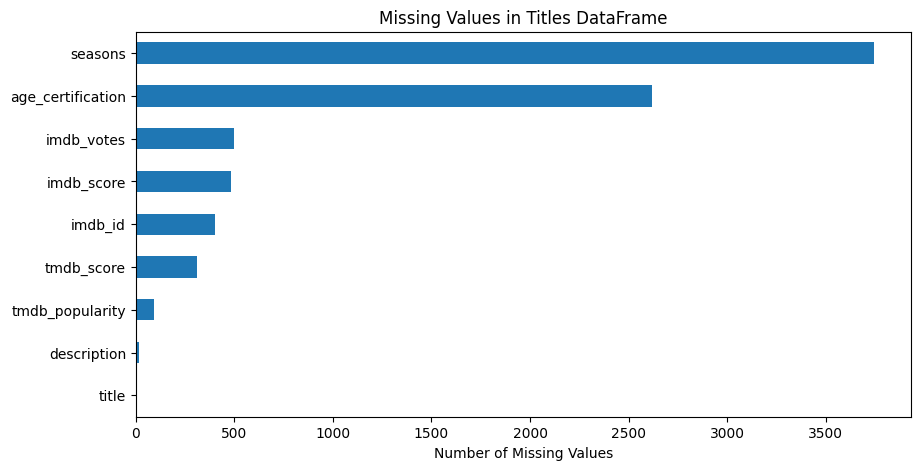

In [ ]:
plt.figure(figsize=(10, 5))
missing_titles[missing_titles > 0].sort_values().plot(kind='barh')
plt.title('Missing Values in Titles DataFrame')
plt.xlabel('Number of Missing Values')
plt.show()

In [ ]:
# seasons: For 'MOVIE' type, NaNs are expected. For 'SHOW', NaNs might mean 1 season or missing data.
# Fill NaN seasons with 0 for movies and 1 for shows if NaN (assuming a show has at least 1 season if listed)
titles_df.loc[titles_df['type'] == 'MOVIE', 'seasons'] = titles_df.loc[titles_df['type'] == 'MOVIE', 'seasons'].fillna(0)
titles_df.loc[titles_df['type'] == 'SHOW', 'seasons'] = titles_df.loc[titles_df['type'] == 'SHOW', 'seasons'].fillna(1)

In [ ]:
# title, age_certification, imdb_id: Impute with 'Unknown'
for col in ['title', 'age_certification', 'imdb_id']:
    titles_df[col] = titles_df[col].fillna('Unknown')

In [ ]:
# imdb_score, imdb_votes, tmdb_popularity, tmdb_score: Impute with median (robust to outliers)
for col in ['imdb_score', 'imdb_votes', 'tmdb_popularity', 'tmdb_score']:
    titles_df[col] = titles_df[col].fillna(titles_df[col].median())

In [ ]:
# description: Impute with an empty string
titles_df['description'] = titles_df['description'].fillna('')

In [ ]:
# genres, production_countries: These are string representations of lists.
# If NaN, it means no genres/countries were listed. Fill with string representation of empty list '[]'
for col in ['genres', 'production_countries']:
    titles_df[col] = titles_df[col].fillna('[]')

In [ ]:
print("\n--- Missing Values After Handling (Titles) ---")
print(titles_df.isna().sum())


--- Missing Values After Handling (Titles) ---
id                      0
title                   0
type                    0
description             0
release_year            0
age_certification       0
runtime                 0
genres                  0
production_countries    0
seasons                 0
imdb_id                 0
imdb_score              0
imdb_votes              0
tmdb_popularity         0
tmdb_score              0
dtype: int64


#### Credits DataFrame

In [ ]:
print("--- Missing Values Before Handling (Credits) ---")
missing_credits = credits_df.isna().sum()
print(missing_credits)

--- Missing Values Before Handling (Credits) ---
person_id       0
id              0
name            0
character    9772
role            0
dtype: int64


In [ ]:
credits_df[credits_df['character'].isna() & (credits_df['role'] != 'DIRECTOR')].head()

,person_id,id,name,character,role
182,548006,tm70993,Peter Brett,NaN,ACTOR
364,557168,tm135083,Loutfi El Hakim,NaN,ACTOR
366,557170,tm135083,F. El Demerdache,NaN,ACTOR
367,557171,tm135083,Said El Araby,NaN,ACTOR
369,557172,tm135083,Hana Abdel Fattah,NaN,ACTOR


In [ ]:
# character: Impute with "N/A"
credits_df['character'] = credits_df['character'].fillna('N/A')

In [ ]:
print("--- Missing Values After Handling (Credits) ---")
print(credits_df.isna().sum())

--- Missing Values After Handling (Credits) ---
person_id    0
id           0
name         0
character    0
role         0
dtype: int64


### 1.4 Data Type Conversion

In [ ]:
print("--- Data Types After Imputation (Titles) ---")
print(titles_df.dtypes)

--- Data Types After Imputation (Titles) ---
id                       object
title                    object
type                     object
description              object
release_year              int64
age_certification        object
runtime                   int64
genres                   object
production_countries     object
seasons                 float64
imdb_id                  object
imdb_score              float64
imdb_votes              float64
tmdb_popularity         float64
tmdb_score              float64
dtype: object


In [ ]:
# seasons, imdb_votes should be 'int'
# imdb_score, tmdb_popularity, tmdb_score can remain 'float'
for col in ['seasons', 'imdb_votes']:
    titles_df[col] = titles_df[col].astype(int)

In [ ]:
print("--- Data Types After Conversion (Titles) ---")
print(titles_df.dtypes)

--- Data Types After Conversion (Titles) ---
id                       object
title                    object
type                     object
description              object
release_year              int64
age_certification        object
runtime                   int64
genres                   object
production_countries     object
seasons                   int64
imdb_id                  object
imdb_score              float64
imdb_votes                int64
tmdb_popularity         float64
tmdb_score              float64
dtype: object


### 1.5 Parse List-like Columns in Titles DataFrame

In [ ]:
# The 'genres' and 'production_countries' columns are strings that look like lists. We need to convert them into actual lists.
import ast
def convert_to_list(string_list):
    try:
        evaluated_list = ast.literal_eval(string_list)
        if isinstance(evaluated_list, list):
            # Ensure all items in the list are strings and clean them
            return [str(item).strip() for item in evaluated_list if str(item).strip()]
        else:
            print(f"Warning: ast.literal_eval did not return a list.")
            return [string_list] if string_list else []

    except (SyntaxError, ValueError):
        return []

titles_df['genres_list'] = titles_df['genres'].apply(convert_to_list)
titles_df['countries_list'] = titles_df['production_countries'].apply(convert_to_list)

titles_df[['genres', 'genres_list', 'production_countries', 'countries_list']].head()

,genres,genres_list,production_countries,countries_list
0,['documentation'],[documentation],['US'],[US]
1,"['drama', 'crime']","[drama, crime]",['US'],[US]
2,"['drama', 'action', 'thriller', 'european']","[drama, action, thriller, european]",['US'],[US]
3,"['fantasy', 'action', 'comedy']","[fantasy, action, comedy]",['GB'],[GB]
4,"['war', 'action']","[war, action]","['GB', 'US']","[GB, US]"


### 1.6 Merge Datasets

In [ ]:
# Merge credits_df into titles_df based on the common 'id' column.
merged_df = pd.merge(titles_df, credits_df, on='id', how='left')

print("--- Merged DataFrame ---")
print("Shape:", merged_df.shape)
print("\nInfo:")
merged_df.info()

--- Merged DataFrame ---
Shape: (78162, 21)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78162 entries, 0 to 78161
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    78162 non-null  object 
 1   title                 78162 non-null  object 
 2   type                  78162 non-null  object 
 3   description           78162 non-null  object 
 4   release_year          78162 non-null  int64  
 5   age_certification     78162 non-null  object 
 6   runtime               78162 non-null  int64  
 7   genres                78162 non-null  object 
 8   production_countries  78162 non-null  object 
 9   seasons               78162 non-null  int64  
 10  imdb_id               78162 non-null  object 
 11  imdb_score            78162 non-null  float64
 12  imdb_votes            78162 non-null  int64  
 13  tmdb_popularity       78162 non-null  float64
 14  tmdb_score         

In [ ]:
print("\nFirst 5 rows:")
merged_df.head()


First 5 rows:


,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score,genres_list,countries_list,person_id,name,character,role
0,ts300399,Five Came Back: The Reference Films,SHOW,This collection includes 12 World War II-era p...,1945,TV-MA,51,['documentation'],['US'],1,Unknown,6.6,2233,0.600,6.900,[documentation],[US],NaN,NaN,NaN,NaN
1,tm84618,Taxi Driver,MOVIE,A mentally unstable Vietnam War veteran works ...,1976,R,114,"['drama', 'crime']",['US'],0,tt0075314,8.2,808582,40.965,8.179,"[drama, crime]",[US],3748.0,Robert De Niro,Travis Bickle,ACTOR
2,tm84618,Taxi Driver,MOVIE,A mentally unstable Vietnam War veteran works ...,1976,R,114,"['drama', 'crime']",['US'],0,tt0075314,8.2,808582,40.965,8.179,"[drama, crime]",[US],14658.0,Jodie Foster,Iris Steensma,ACTOR
3,tm84618,Taxi Driver,MOVIE,A mentally unstable Vietnam War veteran works ...,1976,R,114,"['drama', 'crime']",['US'],0,tt0075314,8.2,808582,40.965,8.179,"[drama, crime]",[US],7064.0,Albert Brooks,Tom,ACTOR
4,tm84618,Taxi Driver,MOVIE,A mentally unstable Vietnam War veteran works ...,1976,R,114,"['drama', 'crime']",['US'],0,tt0075314,8.2,808582,40.965,8.179,"[drama, crime]",[US],3739.0,Harvey Keitel,Matthew 'Sport' Higgins,ACTOR


**Observation:**
- `person_id`, `name`, `character`, `role` columns might have NaNs if an id in `titles_df` had no corresponding entry in `credits_df`.

### 1.7 Aggregate Credit Information

In [ ]:
# We want one row per title, with lists of actors and directors.
# Check 'role' column
merged_df['role'].unique()

array([nan, 'ACTOR', 'DIRECTOR'], dtype=object)

In [ ]:
merged_df['role'] = merged_df['role'].fillna('Unknown')

In [ ]:
# Aggregate actors list
actors = merged_df[merged_df['role'] == 'ACTOR'].groupby('id')['name'].apply(list).reset_index()
actors.rename(columns={'name': 'actors_list'}, inplace=True)

In [ ]:
# Aggregate directors list
directors = merged_df[merged_df['role'] == 'DIRECTOR'].groupby('id')['name'].apply(list).reset_index()
directors.rename(columns={'name': 'directors_list'}, inplace=True)

In [ ]:
# Merge aggregated lists back to titles_df
df_actors = pd.merge(titles_df, actors, on='id', how='left')
df_final = pd.merge(df_actors, directors, on='id', how='left')

In [ ]:
# Fill NaN for actors_list/directors_list with empty lists if a title had no actors/directors
for col in ['actors_list', 'directors_list']:
    df_final[col] = df_final[col].apply(lambda x: x if isinstance(x, list) else [])

In [ ]:
print("--- Final DataFrame with Aggregated Credits ---")
print("Shape:", df_final.shape)
print("\nInfo:")
df_final.info()

--- Final DataFrame with Aggregated Credits ---
Shape: (5850, 19)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5850 entries, 0 to 5849
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    5850 non-null   object 
 1   title                 5850 non-null   object 
 2   type                  5850 non-null   object 
 3   description           5850 non-null   object 
 4   release_year          5850 non-null   int64  
 5   age_certification     5850 non-null   object 
 6   runtime               5850 non-null   int64  
 7   genres                5850 non-null   object 
 8   production_countries  5850 non-null   object 
 9   seasons               5850 non-null   int64  
 10  imdb_id               5850 non-null   object 
 11  imdb_score            5850 non-null   float64
 12  imdb_votes            5850 non-null   int64  
 13  tmdb_popularity       5850 non-null   float64
 14 

In [ ]:
df_final[['title', 'actors_list', 'directors_list']].sample(5)

,title,actors_list,directors_list
5364,The Phantom,[],[Patrick Forbes]
249,Blade Runner: The Final Cut,[],[]
1568,Umrika,"[Suraj Sharma, Tony Revolori, Prateik Babbar, ...",[Prashant Nair]
338,"10,000 BC","[Steven Strait, Camilla Belle, Cliff Curtis, N...",[Roland Emmerich]
216,Breaking Bad,"[Bryan Cranston, Aaron Paul, Anna Gunn, Dean N...",[]


In [ ]:
# Drop the original 'genres' and 'production_countries'
df_final = df_final.drop(columns=['genres', 'production_countries'])

# Rename for consistency
df_final = df_final.rename(columns={'genres_list': 'genres', 'countries_list': 'production_countries'})

In [ ]:
df_final.sample(2)

,id,title,type,description,release_year,age_certification,runtime,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score,genres,production_countries,actors_list,directors_list
283,tm46436,Thir13en Ghosts,MOVIE,"Arthur and his two children, Kathy and Bobby, ...",2001,R,91,0,tt0245674,5.6,87083,50.592,6.2,"[horror, thriller, fantasy]","[CA, US]","[Tony Shalhoub, Embeth Davidtz, Matthew Lillar...",[Steve Beck]
2118,ts80959,Sacred Games,SHOW,A link in their pasts leads an honest cop to a...,2018,TV-MA,50,2,tt6077448,8.5,86279,14.613,8.1,"[action, drama, crime, thriller]",[IN],"[Pankaj Tripathi, Nawazuddin Siddiqui, Chittar...","[Neeraj Ghaywan, Vikramaditya Motwane, Anurag ..."


### 1.8 Text Cleaning (`description`)

In [ ]:
df_final['description'].to_list()[100:105]

['Years ago, the fearsome Pirate King, Gol D. Roger was executed leaving a huge pile of treasure and the famous "One Piece" behind. Whoever claims the "One Piece" will be named the new King of the Pirates. Monkey D. Luffy, a boy who consumed a "Devil Fruit," decides to follow in the footsteps of his idol, the pirate Shanks, and find the One Piece. It helps, of course, that his body has the properties of rubber and that he\'s surrounded by a bevy of skilled fighters and thieves to help him along the way. Luffy will do anything to get the One Piece and become King of the Pirates!',
 "Each Challenge pits numerous cast members from past seasons of reality shows against each other, dividing them into two separate teams according to different criteria, such as gender, which show they first appeared on, whether or not they're veterans or rookies on the show, etc. The two teams compete in numerous missions in order to win prizes and advance in the overall game.",
 "101-year-old Rose DeWitt Buk

In [ ]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Convert to lowercase
    text = text.lower()
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    # Remove punctuation and numbers, keep letters, space
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenize
    words = text.split()
    # Lemmatize and remove stopwords
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words and len(word) > 1]
    # Join the words back into a single string
    cleaned_text = ' '.join(words)
    return cleaned_text

df_final['description_cleaned'] = df_final['description'].apply(clean_text)

In [ ]:
print("Original Description:\n", df_final['description'].iloc[100])
print("\nCleaned Description:\n", df_final['description_cleaned'].iloc[100])

Original Description:
 Years ago, the fearsome Pirate King, Gol D. Roger was executed leaving a huge pile of treasure and the famous "One Piece" behind. Whoever claims the "One Piece" will be named the new King of the Pirates. Monkey D. Luffy, a boy who consumed a "Devil Fruit," decides to follow in the footsteps of his idol, the pirate Shanks, and find the One Piece. It helps, of course, that his body has the properties of rubber and that he's surrounded by a bevy of skilled fighters and thieves to help him along the way. Luffy will do anything to get the One Piece and become King of the Pirates!

Cleaned Description:
 year ago fearsome pirate king gol roger executed leaving huge pile treasure famous one piece behind whoever claim one piece named new king pirate monkey luffy boy consumed devil fruit decides follow footstep idol pirate shank find one piece help course body property rubber he surrounded bevy skilled fighter thief help along way luffy anything get one piece become king p

### 1.9 Final check of the processed DataFrame

In [ ]:
print("--- Final DataFrame ---")
print("Shape:", df_final.shape)
print("\nInfo:")
df_final.info()
print("\nMissing Values:")
print(df_final.isna().sum())

--- Final DataFrame ---
Shape: (5850, 18)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5850 entries, 0 to 5849
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    5850 non-null   object 
 1   title                 5850 non-null   object 
 2   type                  5850 non-null   object 
 3   description           5850 non-null   object 
 4   release_year          5850 non-null   int64  
 5   age_certification     5850 non-null   object 
 6   runtime               5850 non-null   int64  
 7   seasons               5850 non-null   int64  
 8   imdb_id               5850 non-null   object 
 9   imdb_score            5850 non-null   float64
 10  imdb_votes            5850 non-null   int64  
 11  tmdb_popularity       5850 non-null   float64
 12  tmdb_score            5850 non-null   float64
 13  genres                5850 non-null   object 
 14  production_countries  5

In [ ]:
df_final.to_parquet('netflix_processed_data.parquet', engine='pyarrow')

## 2. Exploratory Data Analysis (EDA)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_parquet('https://raw.githubusercontent.com/ava-ly/ds-projects/refs/heads/main/netflix/data/netflix_processed_data.parquet', engine='pyarrow')

In [ ]:
sns.set_style('whitegrid')

In [ ]:
df.sample(5)

,id,title,type,description,release_year,age_certification,runtime,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score,genres,production_countries,actors_list,directors_list,description_cleaned
2381,tm270987,Sahara,MOVIE,A young cobra and his scorpion best friend go ...,2017,Unknown,86,0,tt5246762,5.5,2802,20.636,5.894,"[animation, comedy, family, action, romance, d...","[CA, FR]","[Omar Sy, Louane Emera, Franck Gastambide, Vin...",[Pierre Coré],young cobra scorpion best friend go journey ac...
3037,tm349134,Fabrizio Copano: solo pienso en mí,MOVIE,Fabrizio Copano takes audience participation t...,2017,Unknown,59,0,tt8134310,5.0,34,0.808,5.800,[comedy],[CL],[Fabrizio Copano],"[Rodrigo Toro Solovera, Francisco Schultz]",fabrizio copano take audience participation ne...
5646,tm1049083,Trese After Dark,MOVIE,"Stars and creators gather to discuss ""Trese,"" ...",2021,PG-13,36,0,Unknown,6.6,2233,2.792,7.500,[documentation],[PH],"[Atom Araullo, Yvette Tan, Liza Soberano, Shay...",[],star creator gather discus trese filipino folk...
4963,tm922706,Fear Street: 1666,MOVIE,"In 1666, a colonial town is gripped by a hyste...",2021,R,114,0,Unknown,6.6,2233,89.695,7.300,"[thriller, horror]",[US],"[Kiana Madeira, Ashley Zukerman, Gillian Jacob...",[Leigh Janiak],colonial town gripped hysterical witchhunt dea...
928,tm71148,Thanks for Sharing,MOVIE,A romantic comedy that brings together three d...,2013,R,112,0,tt1932718,6.4,28396,9.986,5.900,"[comedy, drama, romance]",[US],"[Mark Ruffalo, Gwyneth Paltrow, Tim Robbins, J...",[Stuart Blumberg],romantic comedy brings together three disparat...


### 2.1 Univariate Analysis

#### Note: Kernel Density Estimate (`kde=True` in `sns.histplot`):
- A smooth curve that represents the probability density function (PDF) of the underlying data.
- It's useful for visualizing the overall shape, identifying peaks (modes), and understanding the general form of the data distribution without being tied to specific bin widths of a histogram.

#### Distribution of 'type' (Movie vs. Show)

type
MOVIE    3744
SHOW     2106
Name: count, dtype: int64


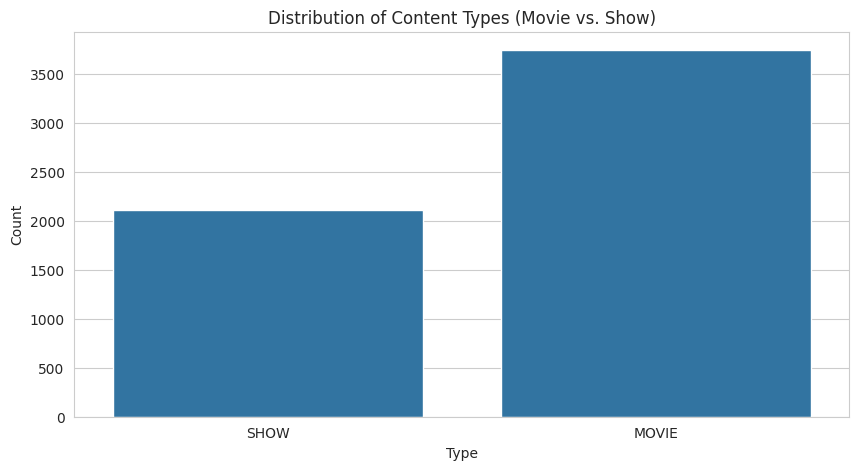

In [ ]:
type_counts = df['type'].value_counts()
print(type_counts)

plt.figure(figsize=(10, 5))
sns.countplot(x='type', data=df)
plt.title('Distribution of Content Types (Movie vs. Show)')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()

#### Distribution of 'release_year'

Earliest Release Year: 1945
Latest Release Year: 2022


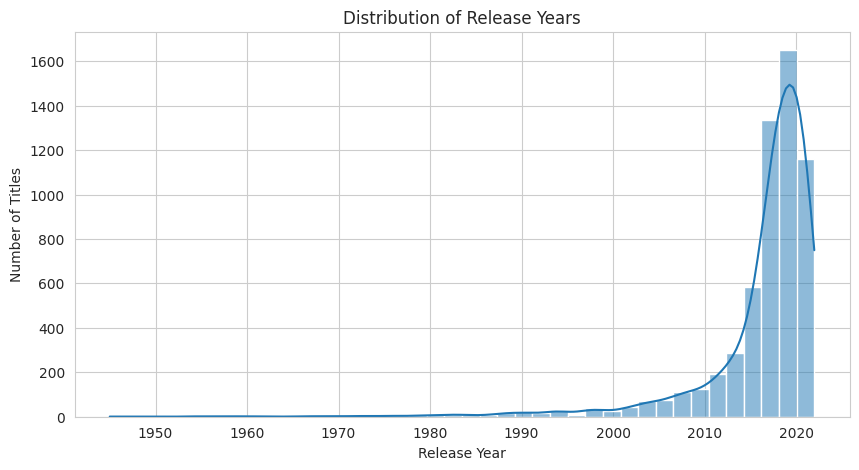

In [ ]:
print(f"Earliest Release Year: {df['release_year'].min()}")
print(f"Latest Release Year: {df['release_year'].max()}")

plt.figure(figsize=(10, 5))
sns.histplot(df['release_year'], bins=40, kde=True)
plt.title('Distribution of Release Years')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.show()

#### Frequency of 'age_certification'

age_certification
Unknown    2619
TV-MA       883
R           556
TV-14       474
PG-13       451
PG          233
TV-PG       188
G           124
TV-Y7       120
TV-Y        107
TV-G         79
NC-17        16
Name: count, dtype: int64


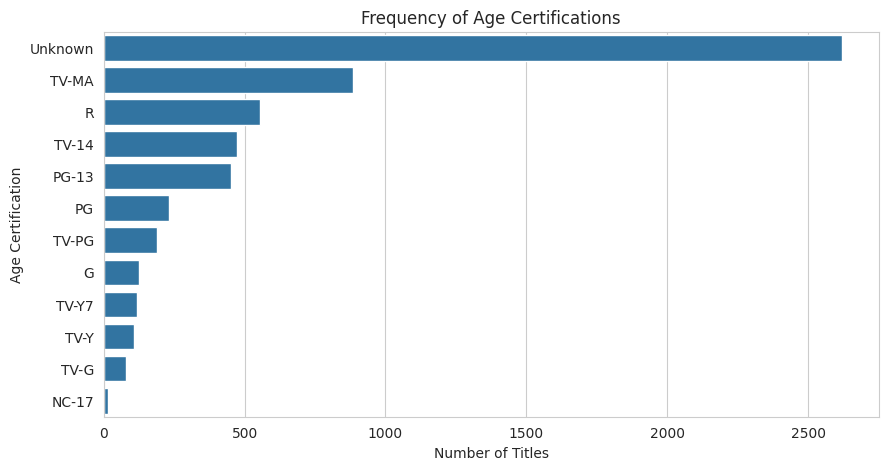

In [ ]:
age_count = df['age_certification'].value_counts()
print(age_count)

plt.figure(figsize=(10, 5))
sns.countplot(data=df, y='age_certification', order=age_count.index)
plt.title('Frequency of Age Certifications')
plt.xlabel('Number of Titles')
plt.ylabel('Age Certification')
plt.show()

#### Distribution of 'runtime' for movies

count    3744.000000
mean       98.213675
std        30.640640
min         2.000000
25%        85.000000
50%        98.000000
75%       115.000000
max       240.000000
Name: runtime, dtype: float64


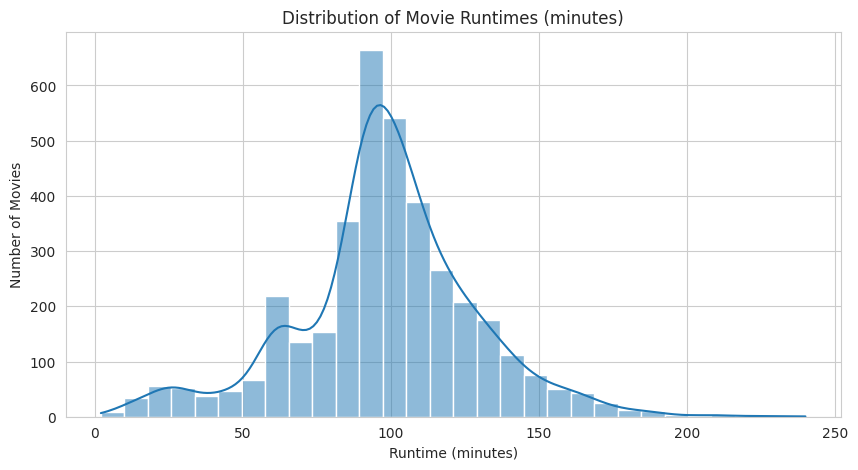

In [ ]:
movie_runtime = df[df['type'] == 'MOVIE']['runtime']
print(movie_runtime.describe())

plt.figure(figsize=(10, 5))
sns.histplot(movie_runtime, bins=30, kde=True)
plt.title('Distribution of Movie Runtimes (minutes)')
plt.xlabel('Runtime (minutes)')
plt.ylabel('Number of Movies')
plt.show()

#### Distribution of 'seasons' for shows

count    2106.000000
mean        2.162868
std         2.689041
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        42.000000
Name: seasons, dtype: float64


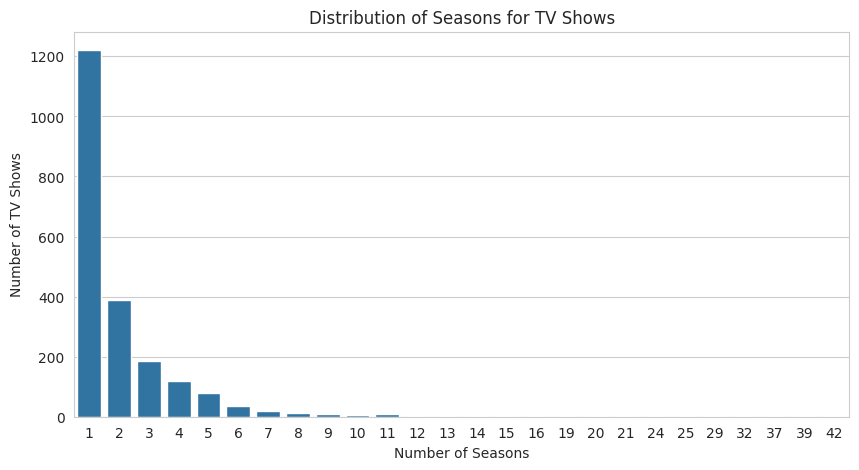

In [ ]:
show_seasons = df[df['type'] == 'SHOW']['seasons']
show_seasons_filtered = show_seasons[show_seasons > 0]
print(show_seasons_filtered.describe())

plt.figure(figsize=(10, 5))
sns.countplot(x=show_seasons_filtered, data=df)
plt.title('Distribution of Seasons for TV Shows')
plt.xlabel('Number of Seasons')
plt.ylabel('Number of TV Shows')
plt.show()

#### Distribution of 'imdb_score'

count    5850.000000
mean        6.518205
std         1.115111
min         1.500000
25%         5.900000
50%         6.600000
75%         7.300000
max         9.600000
Name: imdb_score, dtype: float64


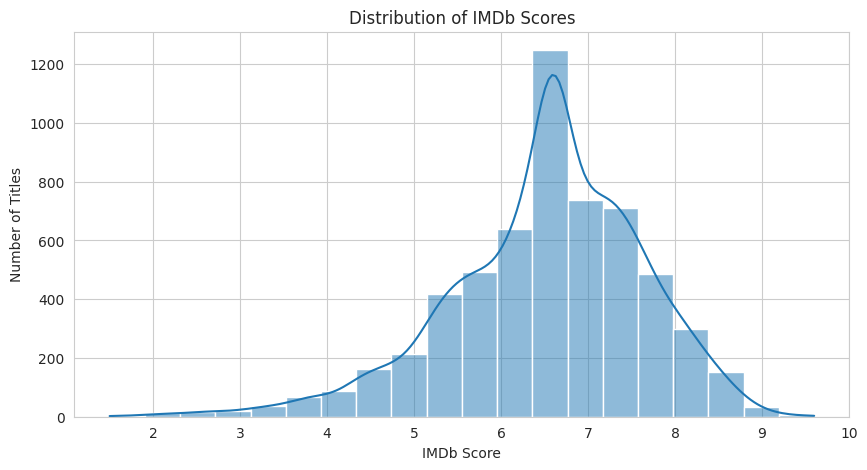

In [ ]:
print(df['imdb_score'].describe())

plt.figure(figsize=(10, 5))
sns.histplot(df['imdb_score'], bins=20, kde=True)
plt.title('Distribution of IMDb Scores')
plt.xlabel('IMDb Score')
plt.ylabel('Number of Titles')
plt.show()

#### Distribution of 'imdb_votes'

count    5.850000e+03
mean     2.163412e+04
std      9.184143e+04
min      5.000000e+00
25%      6.042500e+02
50%      2.233000e+03
75%      7.976000e+03
max      2.294231e+06
Name: imdb_votes, dtype: float64


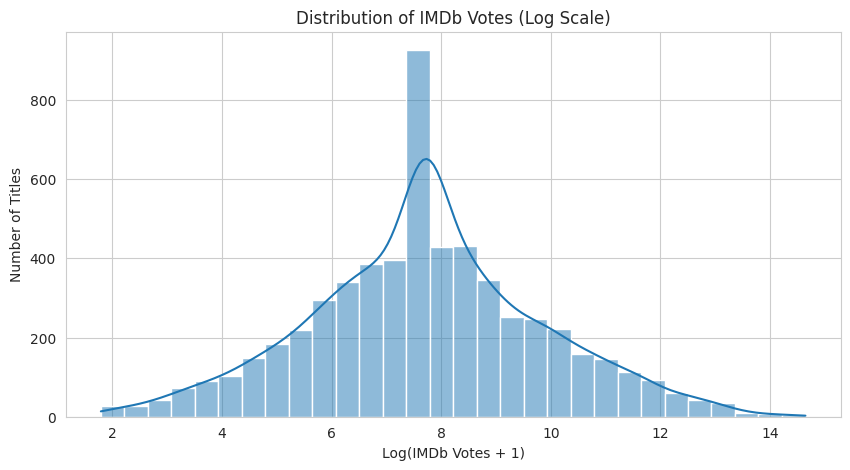

In [ ]:
print(df['imdb_votes'].describe())

# use log scale for better visualization
plt.figure(figsize=(10, 5))
sns.histplot(np.log1p(df['imdb_votes']), bins=30, kde=True)
plt.title('Distribution of IMDb Votes (Log Scale)')
plt.xlabel('Log(IMDb Votes + 1)')
plt.ylabel('Number of Titles')
plt.show()

#### Most common 'genres'

In [ ]:
# The 'genres' column contains lists of genres. We need to flatten it first.
from collections import Counter

# Check genre is not empty
all_genres = [genre for sublist in df['genres'] for genre in sublist if genre]
genre_counts = Counter(all_genres)
top_15_genres = genre_counts.most_common(15)
print(top_15_genres)

[('drama', 2968), ('comedy', 2325), ('thriller', 1228), ('action', 1157), ('romance', 971), ('documentation', 952), ('crime', 936), ('animation', 705), ('family', 682), ('fantasy', 630), ('scifi', 589), ('european', 443), ('horror', 378), ('music', 262), ('history', 254)]


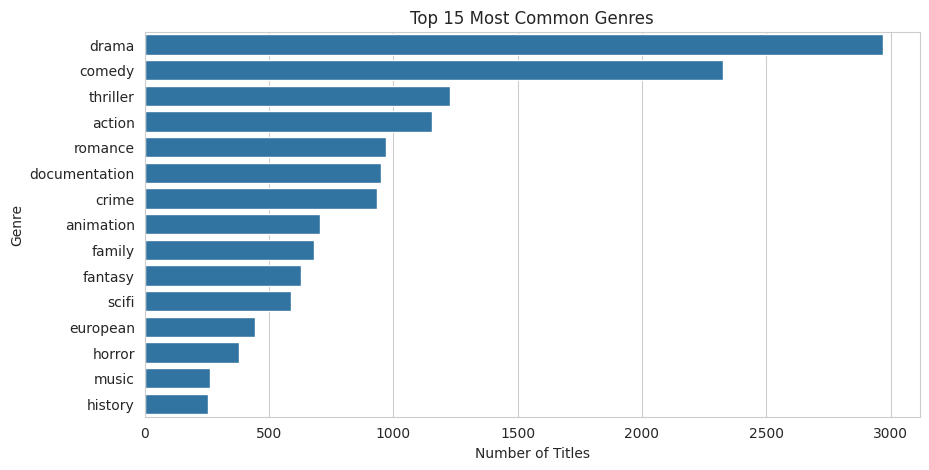

In [ ]:
genre_df = pd.DataFrame(top_15_genres, columns=['genre', 'count'])

plt.figure(figsize=(10, 5))
sns.barplot(data=genre_df, x='count', y='genre')
plt.title('Top 15 Most Common Genres')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.show()

#### Most common 'production_countries'

In [ ]:
!pip install pycountry
import pycountry

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 46.5 MB/s eta 0:00:00


In [ ]:
def get_country(code):
    try:
        country = pycountry.countries.get(alpha_2=code.upper())
        return country.name if country else code
    except (LookupError, AttributeError):
        return code

In [ ]:
all_countries = [country for sublist in df['production_countries'] for country in sublist if country]
country_counts = Counter(all_countries)
top_15_countries = country_counts.most_common(15)
print(top_15_countries)

[('US', 2323), ('IN', 622), ('GB', 404), ('JP', 287), ('FR', 248), ('KR', 228), ('CA', 219), ('ES', 211), ('DE', 139), ('MX', 126), ('BR', 102), ('CN', 102), ('PH', 86), ('AU', 84), ('TR', 84)]


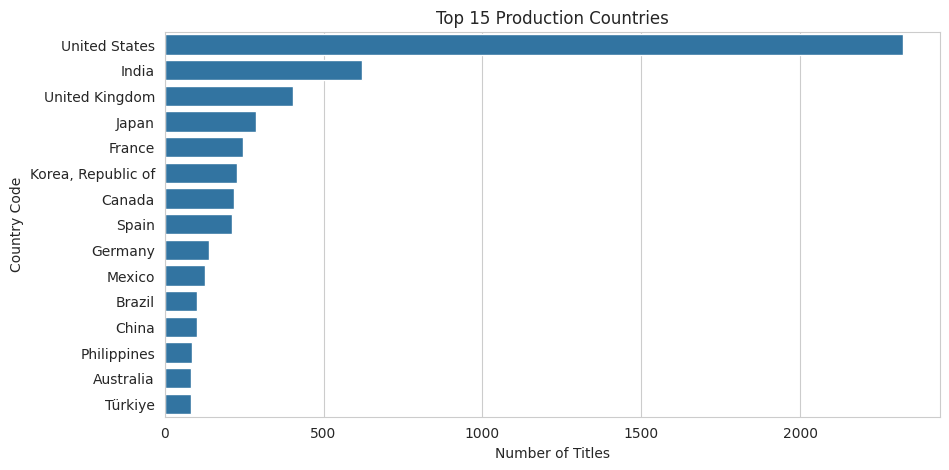

In [ ]:
country_data = []
for code, count in top_15_countries:
    country_name = get_country(code)
    country_data.append({'country_code': code, 'country_name': country_name, 'count': count})

countries_df = pd.DataFrame(country_data)

plt.figure(figsize=(10, 5))
sns.barplot(data=countries_df, x='count', y='country_name')
plt.title('Top 15 Production Countries')
plt.xlabel('Number of Titles')
plt.ylabel('Country Code')
plt.show()

### 2.2 Bivariate & Multivariate Analysis